In [1]:
# 检查 r_tilde 的含义
import numpy as np
data = np.load("cage_jumps_shearrate_0p015.npz", allow_pickle=True)
rt = data["r_tilde"]
print("shape:", rt.shape)         # 应该是 (frames, N, 3)
print("frame0 range:", rt[0].min(), rt[0].max())  # 是坐标范围还是很小的位移值
print("box_Lx:", data["box_Lx"])

shape: (2497, 16500, 3)
frame0 range: 0.0 0.0
box_Lx: 23.9571


In [2]:
# 检查：如果是累积位移，帧1000的位移应该远大于帧10
print("frame 10,  avg |r_tilde|:", np.mean(np.linalg.norm(rt[10], axis=-1)))
print("frame 100, avg |r_tilde|:", np.mean(np.linalg.norm(rt[100], axis=-1)))
print("frame 1000,avg |r_tilde|:", np.mean(np.linalg.norm(rt[1000], axis=-1)))

frame 10,  avg |r_tilde|: 0.47552344
frame 100, avg |r_tilde|: 1.6799045
frame 1000,avg |r_tilde|: 27.466


tχ = 3 frames
对应应变: γ̇·tχ = 0.045  (论文约 0.1~0.3)
图已保存: chi4_curve.png


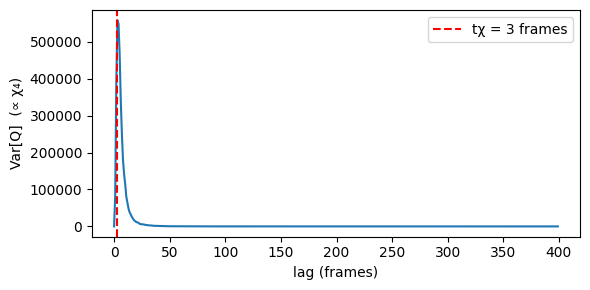

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("cage_jumps_shearrate_0p015_FIXED.npz", allow_pickle=True)
rt   = data["r_tilde"]          # (2497, 16500, 3)
F, N, _ = rt.shape
a    = 0.25

skip      = 200
max_lag   = min(400, F - skip - 2)
n_origins = 40
origins   = np.linspace(skip, F - max_lag - 1, n_origins, dtype=int)

chi4 = np.zeros(max_lag)

for lag in range(1, max_lag):
    dr = rt[origins + lag] - rt[origins]   # (n_origins, N, 3) — 向量化，快
    r2 = np.einsum("tnc,tnc->tn", dr, dr)  # (n_origins, N)
    Q  = (r2 <= a*a).sum(axis=1).astype(float)  # (n_origins,)
    chi4[lag] = Q.var()

tchi_frames = int(np.argmax(chi4))
print(f"tχ = {tchi_frames} frames")
print(f"对应应变: γ̇·tχ = {0.015 * tchi_frames:.3f}  (论文约 0.1~0.3)")

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(np.arange(max_lag), chi4, lw=1.5)
ax.axvline(tchi_frames, color='r', ls='--', label=f'tχ = {tchi_frames} frames')
ax.set_xlabel("lag (frames)"); ax.set_ylabel("Var[Q]  (∝ χ₄)")
ax.legend(); plt.tight_layout()
plt.savefig("chi4_curve.png", dpi=150)
print("图已保存: chi4_curve.png")

In [6]:
import numpy as np
data = np.load("cage_jumps_shearrate_0p015_FIXED.npz", allow_pickle=True)
rt = data["r_tilde"]
F, N, _ = rt.shape

# 如果真实 tχ ~ 15τ₀，对应帧数应该是 15/1.335 ≈ 11 帧
# 但 lag=11 时 mean_Q 已经只剩 1114，chi4=84314
# 而 lag=3 时 chi4=563136，确实是峰值
# 
# 问题：chi4 在 lag=1 时才 79848，说明 lag=1 这一帧
# 已经跨越了真正的上升段，峰值在 lag<1 帧的位置！

print(f"lag=1 时 mean_Q/N = {11742.9/N:.3f}  (应该接近1才说明采样够细)")
print(f"每帧应变增量 = {0.015*1.335:.4f}")
print(f"若真实 tχ~15τ₀，对应 {15/1.335:.1f} 帧")

lag=1 时 mean_Q/N = 0.712  (应该接近1才说明采样够细)
每帧应变增量 = 0.0200
若真实 tχ~15τ₀，对应 11.2 帧


In [5]:
# 检查 dump 文件里相邻帧的时间步差
# 或者直接看 jump_times 换算
jt = data["jump_times"]
jf = data["jump_frames"]
# 找两个相邻帧的事件估算 dt
if len(jf) > 10:
    # 找 jump_frames 差为 1 的事件对
    mask = np.diff(jf) == 1
    if mask.any():
        idx = np.where(mask)[0][0]
        dt_per_frame = jt[idx+1] - jt[idx]
        print(f"每帧物理时间 Δt = {dt_per_frame:.4f} τ₀")
        print(f"tχ=3 frames → {3*dt_per_frame:.4f} τ₀")
        print(f"总模拟时间 = {F * dt_per_frame:.1f} τ₀")

每帧物理时间 Δt = 1.3350 τ₀
tχ=3 frames → 4.0050 τ₀
总模拟时间 = 3333.5 τ₀


In [7]:
import numpy as np

data = np.load("cage_jumps_shearrate_0p015_FIXED.npz", allow_pickle=True)
jump_frames  = data["jump_frames"]
particle_idx = data["particle_idx"]
types        = data["types"]
pos_xy       = data["jump_pos_xy"]
F            = data["r_tilde"].shape[0]

TCHI = 11   # 物理估算值
big_mask = (types[particle_idx] == 1)

# 扫描几个 t0，看每个窗口的点数
print("t0   | 窗口内大粒子事件数")
print("-"*30)
for t0 in np.linspace(F//4, 3*F//4, 10, dtype=int):
    wm   = (jump_frames >= t0) & (jump_frames < t0 + TCHI)
    n    = (big_mask & wm).sum()
    print(f"{t0:5d} | {n}")

t0   | 窗口内大粒子事件数
------------------------------
  624 | 1370
  762 | 1425
  901 | 1618
 1040 | 1721
 1178 | 1767
 1317 | 1890
 1456 | 1947
 1594 | 2063
 1733 | 2143
 1872 | 2177


In [4]:
import numpy as np
import matplotlib.pyplot as plt

blocks = []
current = []
with open('../lammps/rdf.equil.dat') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            if current:
                blocks.append(current)
                current = []
        else:
            vals = line.split()
            if len(vals) == 8:   # bin r gAA coordAA gAB coordAB gBB coordBB
                current.append(list(map(float, vals)))

if current:
    blocks.append(current)

# 找长度一致的块（第一块可能不完整）
lengths = [len(b) for b in blocks]
target  = max(set(lengths), key=lengths.count)
good    = [b for b in blocks if len(b) == target]
print(f"共 {len(good)} 个有效块，每块 {target} 行")

data = np.mean([np.array(b) for b in good], axis=0)
r    = data[:, 1]
g_AA = data[:, 2]
g_AB = data[:, 4]
g_BB = data[:, 6]


共 1 个有效块，每块 500500 行


总行数: 500500
块数: 1001


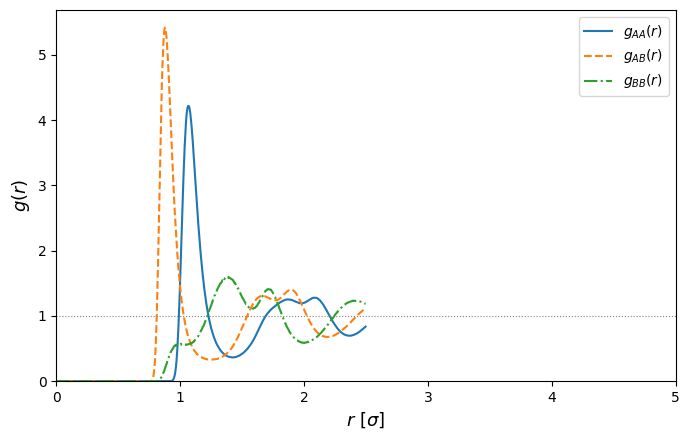

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 只取8列的数据行，跳过所有其他行
rows = []
with open('../lammps/rdf.equil.dat') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#') or not line:
            continue
        vals = line.split()
        if len(vals) == 8:
            rows.append(list(map(float, vals)))

data = np.array(rows)
print(f"总行数: {len(data)}")   # 应该是 500 * n_blocks

# 每块 500 行，reshape 后取平均
n_bins  = 500
n_blocks = len(data) // n_bins
data = data[:n_blocks * n_bins].reshape(n_blocks, n_bins, 8)
print(f"块数: {n_blocks}")

data_avg = data.mean(axis=0)   # (500, 8)
r    = data_avg[:, 1]
g_AA = data_avg[:, 2]
g_AB = data_avg[:, 4]
g_BB = data_avg[:, 6]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(r, g_AA, label=r'$g_{AA}(r)$')
ax.plot(r, g_AB, label=r'$g_{AB}(r)$', ls='--')
ax.plot(r, g_BB, label=r'$g_{BB}(r)$', ls='-.')
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_xlim(0, 5); ax.set_ylim(0)
ax.set_xlabel(r'$r\ [\sigma]$', fontsize=13)
ax.set_ylabel(r'$g(r)$', fontsize=13)
ax.legend(); plt.tight_layout()
plt.savefig('gr_lammps.png', dpi=150)
plt.show()